# Diagnostic Plots — Old 1000-gene LoRA Experiment

**Experiment:** MorphPT + LoRA MLP (10×), 1000 CRC genes, spatial split, mean_r = 0.263

**Three diagnostic plots:**
1. **Variance calibration** — does the model recover dynamic range per gene?
2. **Mean calibration** — does the model systematically over/underpredict any genes?
3. **Spot-level scatter** — 6 representative genes (2 high r, 2 medium r, 2 low r)

**Prerequisites:** `test_y_true.npy` and `test_y_pred.npy` saved by `eval_old_lora_1000.py`.

## 1. Setup & Load

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT     = Path('/hpc/group/jilab/tc459/MorphPT')
OLD_EXP_DIR = PROJECT / 'experiments/visium_morphpt_lora_10x_mlp'

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})

# Load predictions
y_true = np.load(OLD_EXP_DIR / 'test_y_true.npy')
y_pred = np.load(OLD_EXP_DIR / 'test_y_pred.npy')
info   = json.loads((OLD_EXP_DIR / 'eval_info.json').read_text())

N, G = y_true.shape
print(f'Test cells : {N:,}')
print(f'Num genes  : {G}')
print(f'Cache dir  : {info["cache_dir"]}')
print(f'Mean r     : {info["mean_pearson"]:.4f}')

Test cells : 31,459
Num genes  : 1000
Cache dir  : /hpc/group/jilab/tc459/MorphPT/cache_visium
Mean r     : 0.2632


## 2. Load cache stats for de-standardization & coverage

In [4]:
cache_dir = Path(info['cache_dir'])

# Load per-gene mean/std from training statistics (for de-standardization)
stats_file = cache_dir / 'expr_stats.npz'
if stats_file.exists():
    stats_npz      = np.load(stats_file)
    gene_mean_orig = stats_npz['gene_mean']   # (G,)
    gene_std_orig  = stats_npz['gene_std']    # (G,)
    print(f'Loaded expr_stats.npz')
    print(f'  gene_mean_orig range: [{gene_mean_orig.min():.3f}, {gene_mean_orig.max():.3f}]')
    print(f'  gene_std_orig range : [{gene_std_orig.min():.3f}, {gene_std_orig.max():.3f}]')
else:
    # Compute from expr.npy
    print(f'expr_stats.npz not found, computing from expr.npy...')
    meta = pd.read_csv(cache_dir / 'meta.csv')
    train_idx = np.sort(meta[meta['split']=='train']['mmap_idx'].values)
    expr = np.load(str(cache_dir / 'expr.npy'), mmap_mode='r')
    
    sum_x  = np.zeros(G, dtype=np.float64)
    sum_x2 = np.zeros(G, dtype=np.float64)
    for i in range(0, len(train_idx), 5000):
        X = expr[train_idx[i:i+5000]].astype(np.float64)
        sum_x  += X.sum(axis=0)
        sum_x2 += (X**2).sum(axis=0)
    n_train = len(train_idx)
    gene_mean_orig = (sum_x / n_train).astype(np.float32)
    gene_var       = np.clip((sum_x2/n_train) - gene_mean_orig**2, 0, None)
    gene_std_orig  = np.sqrt(gene_var).astype(np.float32)
    print(f'Computed from train cells ({n_train:,} cells)')

# Compute coverage (fraction of train cells expressing each gene)
cov_file = cache_dir / 'gene_coverage.npy'
if cov_file.exists():
    gene_coverage = np.load(cov_file)
    print(f'Loaded gene_coverage.npy')
else:
    print(f'Computing coverage from train cells...')
    meta = pd.read_csv(cache_dir / 'meta.csv')
    train_idx = np.sort(meta[meta['split']=='train']['mmap_idx'].values)
    expr = np.load(str(cache_dir / 'expr.npy'), mmap_mode='r')
    sum_nz = np.zeros(G, dtype=np.float64)
    for i in range(0, len(train_idx), 5000):
        X = expr[train_idx[i:i+5000]]
        sum_nz += (X > 0).sum(axis=0)
    gene_coverage = (sum_nz / len(train_idx)).astype(np.float32)
    np.save(cov_file, gene_coverage)
    print(f'Computed & saved → {cov_file}')

print(f'\nCoverage range: [{gene_coverage.min():.3f}, {gene_coverage.max():.3f}]')

Loaded expr_stats.npz
  gene_mean_orig range: [0.023, 1.593]
  gene_std_orig range : [0.244, 2.220]
Computing coverage from train cells...


PermissionError: [Errno 13] Permission denied: '/hpc/group/jilab/tc459/MorphPT/cache_visium/gene_coverage.npy'

In [3]:
import numpy as np
from pathlib import Path

stats_file = Path('/hpc/group/jilab/rz179/MorphPT_MOE/cache_visium/expr_stats.npz')
stats_npz = np.load(stats_file)
print('Keys in expr_stats.npz:', list(stats_npz.keys()))
for k in stats_npz.keys():
    print(f'  {k}: shape={stats_npz[k].shape}')

Keys in expr_stats.npz: ['gene_mean', 'gene_std']
  gene_mean: shape=(1000,)
  gene_std: shape=(1000,)


## 3. Gene names (optional)

In [ ]:
gene_names = None
for p in [cache_dir / 'gene_list.txt', cache_dir / 'genes.txt']:
    if p.exists():
        candidates = p.read_text().splitlines()
        if len(candidates) == G:
            gene_names = candidates
            print(f'Loaded gene names from {p}')
            break

if gene_names is None:
    gene_names = [f'gene_{i}' for i in range(G)]
    print('No gene names found, using gene_0, gene_1, ...')

## 4. Compute per-gene statistics

Include both z-score space (for variance calibration) and de-standardized space (for mean calibration).

In [ ]:
# Per-gene Pearson r (invariant to standardization)
def pearson_per_gene_np(y_pred, y_true):
    pm  = y_pred - y_pred.mean(axis=0)
    tm  = y_true - y_true.mean(axis=0)
    num = (pm * tm).sum(axis=0)
    den = np.sqrt((pm**2).sum(axis=0) * (tm**2).sum(axis=0)) + 1e-8
    return num / den

# De-standardize: z-score → original expression scale
y_true_orig = y_true * gene_std_orig + gene_mean_orig
y_pred_orig = y_pred * gene_std_orig + gene_mean_orig

# Per-gene stats in BOTH spaces
stats_df = pd.DataFrame({
    'gene_idx':       np.arange(G),
    'gene_name':      gene_names,
    'coverage':       gene_coverage,
    'test_r':         pearson_per_gene_np(y_pred, y_true),
    # Original scale (de-standardized) — for mean calibration
    'true_mean_orig': y_true_orig.mean(axis=0),
    'pred_mean_orig': y_pred_orig.mean(axis=0),
    'true_std_orig':  y_true_orig.std(axis=0),
    'pred_std_orig':  y_pred_orig.std(axis=0),
    # Z-score space — for variance calibration  
    'true_std_z':     y_true.std(axis=0),
    'pred_std_z':     y_pred.std(axis=0),
})

print(f'mean test r: {stats_df["test_r"].mean():.4f}')
print(f'\nSanity: true_std_z should be ~1 (z-score normalized)')
print(f'  true_std_z mean: {stats_df["true_std_z"].mean():.3f}')
print(f'  pred_std_z mean: {stats_df["pred_std_z"].mean():.3f}')
stats_df.head()

## 5. PLOT 1: Variance Calibration

**The most important diagnostic.** Does the model preserve each gene's dynamic range?

- X: std true (z-score space)  
- Y: std predicted (z-score space)
- Color: test Pearson r
- Size: coverage

**Interpretation:**
- Points on y=x → model fully recovers dynamic range (ideal)
- Points below y=x → model shrinks variance (regression to mean)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))

# Scale coverage to point size (2 to 200 visual range)
min_size = 10
max_size = 200
sizes = min_size + (stats_df['coverage'] - stats_df['coverage'].min()) / \
        (stats_df['coverage'].max() - stats_df['coverage'].min()) * (max_size - min_size)

sc = ax.scatter(stats_df['true_std_z'], stats_df['pred_std_z'],
                c=stats_df['test_r'], cmap='RdYlGn',
                vmin=-0.05, vmax=0.8,
                s=sizes, alpha=0.6,
                edgecolor='black', lw=0.3, rasterized=True)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Test Pearson r')

# y=x line
lims = [0, max(stats_df['true_std_z'].max(), stats_df['pred_std_z'].max()) * 1.05]
ax.plot(lims, lims, 'k--', lw=1.2, label='y = x (perfect variance recovery)')

# Fit a linear trend to quantify shrinkage
from numpy.polynomial import polynomial as P
coef = np.polyfit(stats_df['true_std_z'], stats_df['pred_std_z'], 1)
x_fit = np.array(lims)
y_fit = coef[0] * x_fit + coef[1]
ax.plot(x_fit, y_fit, color='blue', lw=1.2, ls='-',
        label=f'best fit: y = {coef[0]:.2f}x + {coef[1]:.2f}')

# Annotate top r genes
top_r = stats_df.nlargest(5, 'test_r')
for _, row in top_r.iterrows():
    ax.annotate(row['gene_name'],
                xy=(row['true_std_z'], row['pred_std_z']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold',
                color='darkgreen')

# Correlation & shrinkage stats
r_std_cal, _ = stats.pearsonr(stats_df['true_std_z'], stats_df['pred_std_z'])
mean_shrink  = 1 - (stats_df['pred_std_z'] / stats_df['true_std_z']).mean()

ax.text(0.05, 0.95,
        f'r(true_std, pred_std) = {r_std_cal:.3f}\n'
        f'mean shrinkage = {mean_shrink:.1%}\n'
        f'slope = {coef[0]:.3f}  (1.0 = perfect)',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Size legend
from matplotlib.lines import Line2D
coverage_levels = [0.05, 0.20, 0.50]
legend_handles  = []
for c in coverage_levels:
    size = min_size + (c - stats_df['coverage'].min()) / \
           (stats_df['coverage'].max() - stats_df['coverage'].min()) * (max_size - min_size)
    legend_handles.append(Line2D([0], [0], marker='o', color='gray',
                                   markersize=np.sqrt(size), linestyle='None',
                                   markeredgecolor='black', markeredgewidth=0.3,
                                   label=f'coverage={c:.0%}'))

first_leg  = ax.legend(loc='lower right', title='', fontsize=8)
second_leg = ax.legend(handles=legend_handles, loc='upper left',
                         bbox_to_anchor=(1.22, 1.0),
                         title='Point size',
                         fontsize=8, framealpha=0.9,
                         borderpad=0.5, handletextpad=1.0)
ax.add_artist(first_leg)

ax.set_xlabel('Std of TRUE expression (z-score space)', fontsize=10)
ax.set_ylabel('Std of PREDICTED expression (z-score space)', fontsize=10)
ax.set_title(f'Plot 1: Variance calibration (1000 genes)\n'
             f'Below y=x means model shrinks dynamic range',
             fontsize=11, fontweight='bold')
ax.set_xlim(lims)
ax.set_ylim(lims)

fig.tight_layout()
plt.show()

print(f'\nKey findings:')
print(f'  Slope (pred_std / true_std): {coef[0]:.3f}')
if coef[0] < 0.9:
    print(f'  → Model shrinks variance by ~{(1-coef[0])*100:.0f}% on average')
    print(f'  → Classic "regression to the mean" — common in MSE training')
elif coef[0] > 1.1:
    print(f'  → Model over-predicts variance (unusual)')
else:
    print(f'  → Variance is well-calibrated')

## 6. PLOT 2: Mean Calibration (de-standardized)

- X: mean true (original scale)
- Y: mean predicted (original scale)
- Color: test Pearson r
- Size: coverage

**Interpretation:** Points should sit on y=x if the model is well-calibrated in mean. Systematic deviations indicate over/under-prediction.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))

sc = ax.scatter(stats_df['true_mean_orig'], stats_df['pred_mean_orig'],
                c=stats_df['test_r'], cmap='RdYlGn',
                vmin=-0.05, vmax=0.8,
                s=sizes, alpha=0.6,
                edgecolor='black', lw=0.3, rasterized=True)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Test Pearson r')

# y=x
lims = [min(stats_df['true_mean_orig'].min(),
            stats_df['pred_mean_orig'].min()) - 0.05,
        max(stats_df['true_mean_orig'].max(),
            stats_df['pred_mean_orig'].max()) + 0.05]
ax.plot(lims, lims, 'k--', lw=1.2, label='y = x')

# Annotate top genes
for _, row in top_r.iterrows():
    ax.annotate(row['gene_name'],
                xy=(row['true_mean_orig'], row['pred_mean_orig']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold',
                color='darkgreen')

r_mean_cal, _ = stats.pearsonr(stats_df['true_mean_orig'],
                                stats_df['pred_mean_orig'])
# Mean absolute error of per-gene mean
mae = (stats_df['pred_mean_orig'] - stats_df['true_mean_orig']).abs().mean()

ax.text(0.05, 0.95,
        f'r(true_mean, pred_mean) = {r_mean_cal:.3f}\n'
        f'mean abs error = {mae:.4f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.legend(loc='lower right')
ax.set_xlabel('Mean TRUE expression (original scale)', fontsize=10)
ax.set_ylabel('Mean PREDICTED expression (original scale)', fontsize=10)
ax.set_title(f'Plot 2: Mean calibration (1000 genes, de-standardized)\n'
             f'Each point = 1 gene, size = coverage',
             fontsize=11, fontweight='bold')
ax.set_xlim(lims)
ax.set_ylim(lims)
fig.tight_layout()
plt.show()

## 7. PLOT 3: Spot-level Scatter for 6 Representative Genes

In [ ]:
# Select 6 genes: 2 high r, 2 medium r, 2 low r
stats_sorted = stats_df.sort_values('test_r', ascending=False).reset_index(drop=True)

# High r: top 2 with high variance (cell-type markers)
high_r = stats_sorted.head(2).copy()
high_r['tier'] = 'high r'

# Medium r: around the median Pearson r
n         = len(stats_sorted)
mid_start = n // 2 - 1
mid_r     = stats_sorted.iloc[mid_start:mid_start+2].copy()
mid_r['tier'] = 'medium r'

# Low r: bottom 2 (but not tied at r~0 if possible)
low_r     = stats_sorted.tail(2).copy()
low_r['tier'] = 'low r'

selected = pd.concat([high_r, mid_r, low_r], ignore_index=True)

print('Selected 6 genes for spot-level scatter:')
print(selected[['gene_name', 'coverage', 'true_std_z', 'test_r', 'tier']].to_string(index=False))

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(11, 14))
tier_colors = {'high r':   '#2d6a4f',
               'medium r': '#F0B441',
               'low r':    '#C44E52'}

for i, (_, row) in enumerate(selected.iterrows()):
    ax   = axes[i // 2, i % 2]
    idx  = int(row['gene_idx'])
    name = row['gene_name']
    r    = row['test_r']
    tier = row['tier']
    cov  = row['coverage']

    true_vals = y_true[:, idx]
    pred_vals = y_pred[:, idx]

    # Hexbin for density (too many cells for scatter)
    hb = ax.hexbin(true_vals, pred_vals, gridsize=50,
                   cmap='viridis', bins='log', mincnt=1,
                   rasterized=True)
    plt.colorbar(hb, ax=ax, label='log count', fraction=0.04, pad=0.04)

    # y=x
    lims = [min(true_vals.min(), pred_vals.min()) - 0.1,
            max(true_vals.max(), pred_vals.max()) + 0.1]
    ax.plot(lims, lims, 'r--', lw=1.2, alpha=0.8, label='y=x')

    # Title with gene info
    ax.set_title(f'{name}  (r = {r:.3f}, coverage = {cov:.2%})',
                 color=tier_colors[tier], fontweight='bold', fontsize=11)
    ax.set_xlabel('True expression (z-score)')
    ax.set_ylabel('Predicted expression (z-score)')

    # Tier label in corner
    ax.text(0.05, 0.95, tier.upper(),
            transform=ax.transAxes, fontsize=10, va='top',
            color=tier_colors[tier], fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white',
                     edgecolor=tier_colors[tier], alpha=0.9))

    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

fig.suptitle('Plot 3: Spot-level scatter — 6 representative genes\n'
             '(each point = 1 test spot, color = density)',
             fontweight='bold', fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

## 8. Summary of diagnostic findings

In [ ]:
print(f'{"="*60}')
print(f'Diagnostic summary — Old 1000-gene LoRA')
print(f'{"="*60}')
print()
print(f'Model metrics:')
print(f'  mean Pearson r   : {stats_df["test_r"].mean():.4f}')
print(f'  median Pearson r : {stats_df["test_r"].median():.4f}')
print()
print(f'Variance calibration (Plot 1):')
print(f'  r(true_std, pred_std) = {r_std_cal:.3f}')
print(f'  Best-fit slope        = {coef[0]:.3f}  (1.0 = perfect)')
print(f'  Mean shrinkage        = {mean_shrink:.1%}')
print()
print(f'Mean calibration (Plot 2):')
print(f'  r(true_mean, pred_mean) = {r_mean_cal:.3f}')
print(f'  Mean abs error (orig scale) = {mae:.4f}')
print()
print(f'Top 5 genes (Plot 3 candidates):')
print(stats_sorted.head(5)[['gene_name', 'coverage', 'true_std_z', 'test_r']].to_string(index=False))

# Save merged analysis
out = OLD_EXP_DIR / 'diagnostic_stats.csv'
stats_df.to_csv(out, index=False)
print(f'\nSaved → {out}')

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    '/hpc/group/jilab/tc459/MorphPT/experiments/'
    'lora_probing_crc_multi_10.0x_mse/multi_lora_hybrid_results.csv'
)

df_sorted = df.sort_values('test_pearson_s42', ascending=False)

print("Top-N analysis for LoRA (MSE):\n")
for N in [10, 20, 50, 100, 200, 400]:
    subset = df_sorted.head(N)
    mean_r = subset['test_pearson_s42'].mean()
    median_r = subset['test_pearson_s42'].median()
    print(f"  Top {N:>3d}: mean={mean_r:.4f}, median={median_r:.4f}")

print(f"\n🏆 Top 20 genes by LoRA test R:")
print(df_sorted.head(20)[['gene_name', 'test_pearson_s42']].to_string(index=False))

Top-N analysis for LoRA (MSE):

  Top  10: mean=0.7798, median=0.7653
  Top  20: mean=0.7066, median=0.6985
  Top  50: mean=0.6040, median=0.5801
  Top 100: mean=0.5128, median=0.4821
  Top 200: mean=0.4228, median=0.3805
  Top 400: mean=0.3218, median=0.2932

🏆 Top 20 genes by LoRA test R:
gene_name  test_pearson_s42
     PIGR          0.942896
      VIM          0.824854
  CEACAM5          0.782501
   COL3A1          0.779926
  CEACAM6          0.769953
    SPARC          0.760716
   COL1A1          0.759438
     IGKC          0.732030
    MUC12          0.729296
   COL1A2          0.716063
    EPCAM          0.680854
     PYGB          0.661727
   IGFBP7          0.655045
     LCN2          0.645368
   LGALS1          0.640946
   COL4A1          0.629099
    PHGR1          0.615598
   COL6A2          0.615181
     FTH1          0.595986
    IGHG1          0.593569


In [3]:
import pandas as pd

df = pd.read_csv('/hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_crc_multi_10.0x_mixed_c0.2_v0.05/multi_lora_hybrid_results.csv')
df_sorted = df.sort_values('test_pearson_s42', ascending=False)

for N in [10, 20, 50, 100, 200, 400]:
    print(f"Top {N:>3d}: mean={df_sorted.head(N)['test_pearson_s42'].mean():.4f}")

print("\nTop 20 genes (Mixed LoRA):")
print(df_sorted.head(20)[['gene_name', 'test_pearson_s42']].to_string(index=False))

Top  10: mean=0.7797
Top  20: mean=0.7059
Top  50: mean=0.6041
Top 100: mean=0.5132
Top 200: mean=0.4234
Top 400: mean=0.3228

Top 20 genes (Mixed LoRA):
gene_name  test_pearson_s42
     PIGR          0.941247
      VIM          0.825098
  CEACAM5          0.784531
   COL3A1          0.778438
  CEACAM6          0.775228
    SPARC          0.759402
   COL1A1          0.758079
    MUC12          0.730680
     IGKC          0.728888
   COL1A2          0.715066
    EPCAM          0.681474
     PYGB          0.661719
   IGFBP7          0.653207
   LGALS1          0.642081
     LCN2          0.640045
   COL4A1          0.625954
    PHGR1          0.616338
   COL6A2          0.612453
     FTH1          0.598472
    IGHG1          0.589900


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 统一一下绘图的美观风格
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
# 1. 你的模型预测结果
res_path = '/hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_crc_multi_10.0x_mixed_c0.2_v0.05/multi_lora_hybrid_results.csv'
df_res = pd.read_csv(res_path)

# 2. 我们刚刚跑通的切片/基因统计信息
stats_path = '/hpc/group/jilab/tc459/MorphPT/cache_crc/per_gene_split_stats_seed_42.csv'
df_stats = pd.read_csv(stats_path)

# 3. 按基因名融合在一起
df = pd.merge(df_res, df_stats, on='gene_name', how='inner')
print(f"✅ 成功融合数据！表维度: {df.shape}")

# 按 test_pearson_s42 降序排列，方便后续取 Top N
df_sorted = df.sort_values('test_pearson_s42', ascending=False)


✅ 成功融合数据！表维度: (400, 31)


In [3]:
print("📈 ============ Top N 平均 Pearson Correlation ============")
for N in [10, 20, 50, 100, 200, 400]:
    if N <= len(df_sorted):
        print(f"Top {N:>3d}: mean = {df_sorted.head(N)['test_pearson_s42'].mean():.4f}")

print("\n🧬 ============ Top 20 表现最好的基因 (Mixed LoRA) ============")
# 除了 Pearson R，额外打印这个基因在测试集里的覆盖率，以及在训练集里的绝对细胞数
display_cols = ['gene_name', 'test_pearson_s42', 'test_coverage', 'train_nonzero']
print(df_sorted.head(20)[display_cols].to_string(index=False))


📈 ============ Top N 平均 Pearson Correlation ============
Top  10: mean = 0.7797
Top  20: mean = 0.7059
Top  50: mean = 0.6041
Top 100: mean = 0.5132
Top 200: mean = 0.4234
Top 400: mean = 0.3228

🧬 ============ Top 20 表现最好的基因 (Mixed LoRA) ============
gene_name  test_pearson_s42  test_coverage  train_nonzero
     PIGR          0.941247       0.222476          11883
      VIM          0.825098       0.315241          40996
  CEACAM5          0.784531       0.714768         106847
   COL3A1          0.778438       0.281894          36549
  CEACAM6          0.775228       0.603661         100918
    SPARC          0.759402       0.201921          27585
   COL1A1          0.758079       0.227916          31242
    MUC12          0.730680       0.712142         100577
     IGKC          0.728888       0.446903          49304
   COL1A2          0.715066       0.194531          25798
    EPCAM          0.681474       0.691399          97917
     PYGB          0.661719       0.584718          

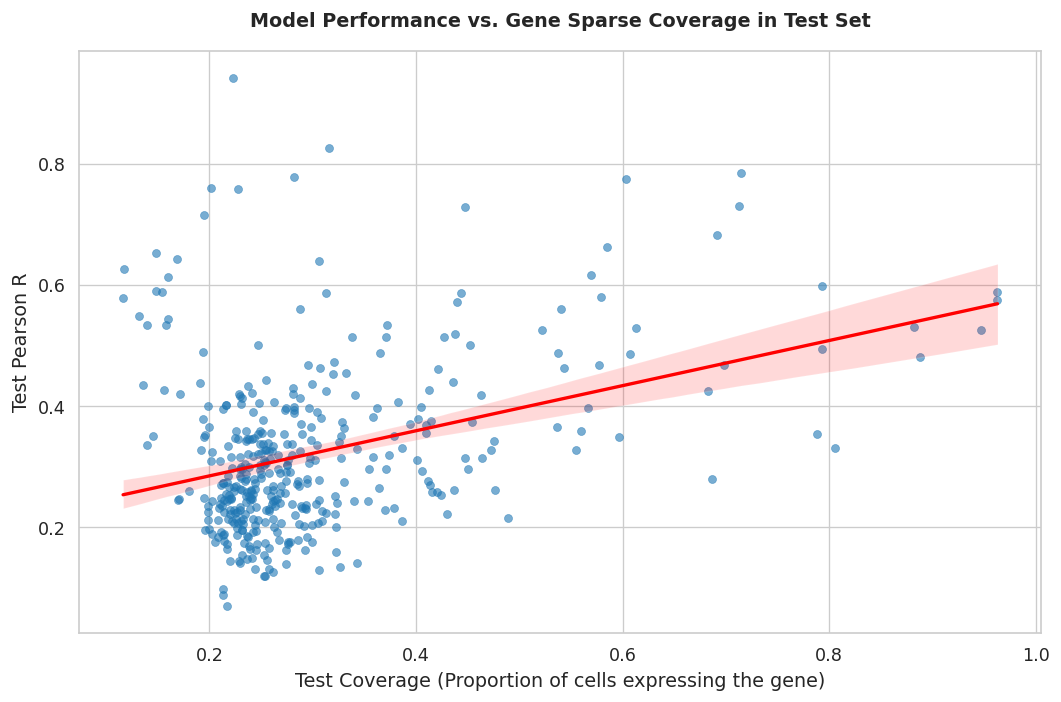

In [4]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df, 
    x='test_coverage', 
    y='test_pearson_s42',
    alpha=0.6,
    edgecolor=None,
    color='#1f77b4' # 经典的绝地蓝色
)

# 添加一条红色的线性趋势线
sns.regplot(
    data=df, 
    x='test_coverage', 
    y='test_pearson_s42',
    scatter=False, 
    color='red',
    line_kws={"linewidth": 2}
)

plt.title('Model Performance vs. Gene Sparse Coverage in Test Set', pad=15, fontweight='bold')
plt.xlabel('Test Coverage (Proportion of cells expressing the gene)')
plt.ylabel('Test Pearson R')
plt.tight_layout()
plt.show()


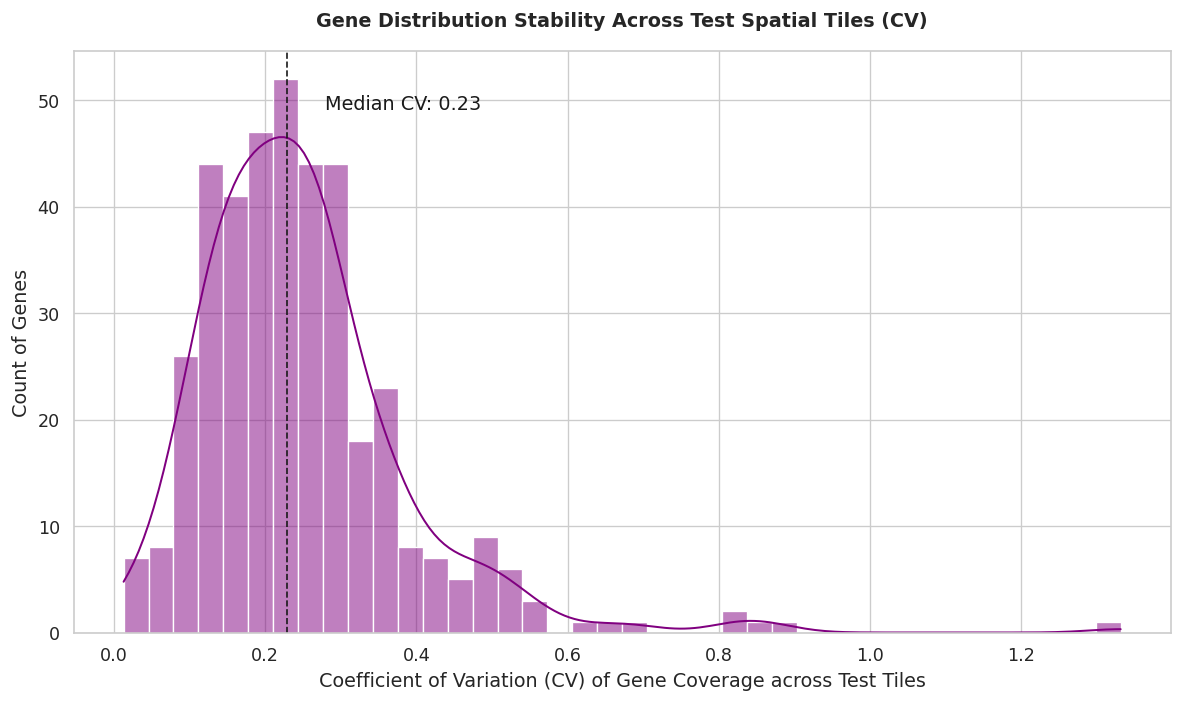

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['tile_coverage_cv'], 
    bins=40, 
    kde=True,
    color='purple'
)

plt.title('Gene Distribution Stability Across Test Spatial Tiles (CV)', pad=15, fontweight='bold')
plt.xlabel('Coefficient of Variation (CV) of Gene Coverage across Test Tiles')
plt.ylabel('Count of Genes')

# 标注：CV 越大说明这个基因在不同的测试图片(Tile)中很不平稳
plt.axvline(df['tile_coverage_cv'].median(), color='k', linestyle='dashed', linewidth=1)
plt.text(df['tile_coverage_cv'].median() + 0.05, plt.ylim()[1]*.9, f'Median CV: {df["tile_coverage_cv"].median():.2f}', color='k')

plt.tight_layout()
plt.show()
